In [1]:
"""Configuration and lazy connection factories for dataloader."""

from __future__ import annotations

from functools import lru_cache

from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import pymssql
from pathlib import Path

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
# 中文说明：`corr`：执行该名称对应的业务计算，并返回调用方所需结果。
import bottleneck as bn

def corr(a, b, axis):
    b[np.isnan(a)] = np.nan
    a[np.isnan(b)] = np.nan
    arr = (
            (bn.nanmean(a * b, axis=axis) - bn.nanmean(a, axis=axis) * bn.nanmean(b, axis=axis))
            / (bn.nanstd(a, axis=axis) + 1e-6)
            / (bn.nanstd(b, axis=axis) + 1e-6)
    )
    bn.replace(arr, np.nan, 0)
    arr[np.isinf(arr)] = 0
    return arr

# 中文说明：`IC`：执行该名称对应的业务计算，并返回调用方所需结果。
def IC(y_, y):
    ics = corr(y_.copy(), y.copy(), axis=-1)
    return ics

# 中文说明：`rankIC`：执行该名称对应的业务计算，并返回调用方所需结果。
def rankIC(y_, y):
    rank_ics = corr(bn.nanrankdata(y_.copy(), axis=-1), bn.nanrankdata(y.copy(), axis=-1), axis=-1)
    return rank_ics

# 中文说明：`calc_group_ret`：计算研究或生产指标。
def calc_group_ret(alpha, label, num_group=10):
    rank = bn.nanrankdata(alpha, axis=-1)
    num_signal = np.nanmax(rank, axis=-1)
    stock_each_group = num_signal // num_group
    group_ret = np.full((num_group, num_signal.shape[0]), np.nan)
    for i in range(num_group):
        if i==num_group-1:
            group_ix = (rank.T > stock_each_group * i) & (rank.T <= num_signal)
        else:
            group_ix = (rank.T > stock_each_group * i) & (rank.T <= stock_each_group * (i + 1)) # n_stock, n_date
        temp_ret = label.copy()
        temp_ret[~group_ix.T] = np.nan
        group_ret[i] = np.nanmean(temp_ret, axis=-1)
    group_ret = group_ret - np.nanmean(group_ret, axis=0)
    return group_ret

In [93]:
ZYYX_URL = URL.create(
    drivername="mssql+pymssql",
    username="zyyxReader",
    password="zyyx!5893@Fund",
    host="10.110.0.106",
    database="zyyx",
    query={"charset": "utf8"},
)
@lru_cache(maxsize=1)
def get_zyyx_conn():
    engine = create_engine(
        ZYYX_URL,
        connect_args={
            "tds_version": "7.0",
            "charset": "utf8",
        },
    )
    return engine.connect()

In [94]:
start='2012-01-01'
asof='2020-12-31'
pre_asof='2013-01-01'
conn = get_zyyx_conn()

In [95]:
sql = f"""
SELECT
    f.id, f.report_id, f.stock_code, f.organ_id, ra.author_id,
    f.report_year, f.report_quarter,
    f.create_date, f.entrytime, 
    f.forecast_np, f.gg_rating_code AS rating_score, f.target_price_ceiling, f.target_price_floor
FROM rpt_forecast_stk f
JOIN rpt_report_author ra ON ra.report_id = f.report_id
WHERE f.create_date BETWEEN '{start}' AND '{asof}'
    AND f.entrytime <= '{asof} 23:59:59'
    AND DATEDIFF(day, f.create_date, f.entrytime) BETWEEN 0 AND 7
    AND f.forecast_np IS NOT NULL
    AND (f.reliability >= 5 OR f.reliability IS NULL)
    AND f.organ_id IS NOT NULL
    AND ra.author_id IS NOT NULL
    AND f.gg_rating_code IN ('1','2','3','5','7')
"""
history = (
    pl.read_database(sql, conn, infer_schema_length=None)
    .with_columns(
        pl.col("stock_code").cast(pl.String).str.zfill(6).alias("tick"),
        pl.col("organ_id").cast(pl.Int64, strict=False),
        pl.col("author_id").cast(pl.Int64, strict=False),
        pl.col("create_date").cast(pl.Date, strict=False),
        pl.col("entrytime").cast(pl.Datetime, strict=False),
        pl.col("forecast_np").cast(pl.Float64, strict=False),
    )
    .filter(pl.col("tick").is_not_null() & pl.col("forecast_np").is_finite())
    .sort([
        "tick", "author_id", 'report_year','report_quarter', "create_date", "entrytime", "report_id", "id",
    ]).unique(
        ["report_id", "tick", "organ_id", "author_id", "report_year"],
        keep="last", maintain_order=True,
    )
)

history.write_parquet('history_rpt_20120101_20201231.pq')

In [96]:
history = pl.read_parquet('history_rpt_20120101_20201231.pq')

In [ ]:
dates = pd.to_datetime(np.load("/data/shanghai/xujiayi/workflow/data/axis/dates.npy", allow_pickle=True))
pre_asof = pd.Timestamp(pre_asof)
asof = pd.Timestamp(asof)
mask = (dates >= pre_asof) & (dates <= asof)
dates = dates[mask]
pre_asof_dt = dates.searchsorted(pre_asof)
asof_dt = dates.searchsorted(asof)

ticks = np.load('/data/shanghai/xujiayi/workflow/data/axis/stock_ticks.npy', allow_pickle=True)
valid_ticks = [tick for tick in ticks if tick!='']
positions = [i for i,tick in enumerate(ticks) if tick!='']

tradable = np.memmap('/data/shanghai/xujiayi/workflow/data/stock/basic/tradable.bin',shape=(len(dates),len(ticks)),dtype=np.float32,mode='r')
tradable = tradable[pre_asof_dt:asof_dt+1, positions]
tick_positions = pl.DataFrame({
    "tick": valid_ticks,
    "position": np.arange(len(valid_ticks)),
})

OSError: [WinError 8] 内存资源不足，无法处理此命令。

In [ ]:
pct = np.memmap("/data/shanghai/xujiayi/workflow/data/stock/d_essentials/pct.bin", mode='r', dtype=np.float32, shape=(len(dates),len(ticks)))
pct = pct[pre_asof_dt:asof_dt+1,positions]/100

windows = np.lib.stride_tricks.sliding_window_view(
    pct[2:], 10, axis=0
)
forward_return = np.prod(1.0 + windows, axis=-1) - 1.0

label = np.full((len(dates),len(valid_ticks)), np.nan)
label[:len(forward_return)] = forward_return
label

array([[-0.04592305, -0.02895671,  0.        , ...,         nan,
                nan,         nan],
       [-0.06637651, -0.0579142 ,  0.        , ...,         nan,
                nan,         nan],
       [ 0.0013231 , -0.04669195,  0.        , ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(730, 4616))

In [ ]:
mv = np.memmap("/data/shanghai/xujiayi/workflow/data/stock/d_essentials/circ_mv.bin", mode='r', dtype=np.float32, shape=(len(dates),len(ticks)))
mv = mv[pre_asof_dt:asof_dt+1,positions]
lagged_mv = np.full_like(mv, np.nan)
lagged_mv[1:] = mv[:-1]

valid_market = (
    np.isfinite(pct)
    & np.isfinite(lagged_mv)
    & (lagged_mv > 0)
)

market_numerator = np.sum(
    np.where(
        valid_market,
        pct * lagged_mv,
        0.0,
    ),
    axis=1,
)

market_denominator = np.sum(
    np.where(
        valid_market,
        lagged_mv,
        0.0,
    ),
    axis=1,
)

market_pct = np.divide(
    market_numerator,
    market_denominator,
    out=np.full(len(pct), np.nan),
    where=market_denominator > 0,
)

valid_excess = (
    np.isfinite(pct)
    & (pct > -1)
    & np.isfinite(market_pct[:, None])
    & (market_pct[:, None] > -1)
)

daily_excess_log_return = np.where(
    valid_excess,
    np.log1p(pct)
    - np.log1p(market_pct[:, None]),
    0.0,
)

n_dates, n_stocks = daily_excess_log_return.shape

excess_prefix = np.zeros(
    (n_dates + 1, n_stocks),
    dtype=np.float64,
)

excess_prefix[1:] = np.cumsum(
    daily_excess_log_return,
    axis=0,
)

excess_prefix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.0255235 , -0.03098251, -0.00808024, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.12264311,  0.27947972,  0.08887301, ...,  0.        ,
         0.        ,  0.        ],
       [-0.11078705,  0.26476883,  0.07294038, ...,  0.        ,
         0.        ,  0.        ],
       [-0.11342939,  0.26400124,  0.06481075, ...,  0.        ,
         0.        ,  0.        ]], shape=(731, 4616))

In [75]:
def _residual(y, x):
    """Return OLS residuals for one or more regressors without inversion."""
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x[:, None]
    if x.ndim != 2 or len(x) != len(y):
        raise ValueError("x must have shape (n_samples, n_regressors)")

    out = np.full(y.shape, np.nan)
    ok = np.isfinite(y) & np.all(np.isfinite(x), axis=1)
    if ok.sum() <= x.shape[1] + 1:
        out[ok] = y[ok]
        return out
    design = np.column_stack((np.ones(ok.sum()), x[ok]))
    coefficients = np.linalg.lstsq(design, y[ok], rcond=None)[0]
    out[ok] = y[ok] - design @ coefficients
    return out


In [80]:
# COV
cov = np.full((len(dates),len(valid_ticks)),np.nan)
for date in dates:
    pre_date = date - pd.Timedelta(days=90)
    hist = history.filter(
        (pl.col('create_date') >= pre_date) &
        (pl.col('create_date') <= date)
    )
    total_report_count = hist['report_id'].n_unique()
    frame = (
        hist
        .group_by("tick")
        .agg(
            (
                pl.col("report_id").n_unique() / total_report_count
            )
            .cast(pl.Float64)
            .sqrt()
            .alias('cov')
        ).with_columns(
            
        )
    )
    frame = (
        frame
        .with_columns(
            pl.col('tick').cast(pl.String).str.zfill(6)
        )
        .join(
            tick_positions,
            on='tick',
            how='inner'
        )
    )

    start_row = np.searchsorted(dates,np.datetime64(pre_date.date()),side="right")
    end_row = np.searchsorted(dates,date,side="right")
    positions = (frame["position"].to_numpy().astype(np.int64))
    
    valid_positions = ( (positions >= 0) & (positions < pct.shape[1]) )
    excess_momentum = np.full(len(frame), np.nan)
    valid_cols = positions[valid_positions]
    excess_log_momentum = (
        excess_prefix[end_row, valid_cols]
        - excess_prefix[start_row, valid_cols]
    )
    excess_momentum[valid_positions] = np.expm1(
        excess_log_momentum
    )
    
    frame = frame.with_columns(
        pl.Series('excess_mom', excess_momentum)
    ).with_columns(
        pl.Series("cov", _residual(frame["cov"], excess_momentum))
    )

    cov[np.searchsorted(dates,date), frame['position'].to_numpy()] = frame['cov'].to_numpy()
cov
    
cov = np.where(tradable,cov,np.nan)

C:\Users\xujiayi\AppData\Local\Temp\ipykernel_26620\266143508.py:29: RuntimeWarning: All-NaN slice encountered
  num_signal = np.nanmax(rank, axis=-1)
C:\Users\xujiayi\AppData\Local\Temp\ipykernel_26620\266143508.py:39: RuntimeWarning: Mean of empty slice
  group_ret[i] = np.nanmean(temp_ret, axis=-1)
C:\Users\xujiayi\AppData\Local\Temp\ipykernel_26620\266143508.py:40: RuntimeWarning: Mean of empty slice
  group_ret = group_ret - np.nanmean(group_ret, axis=0)


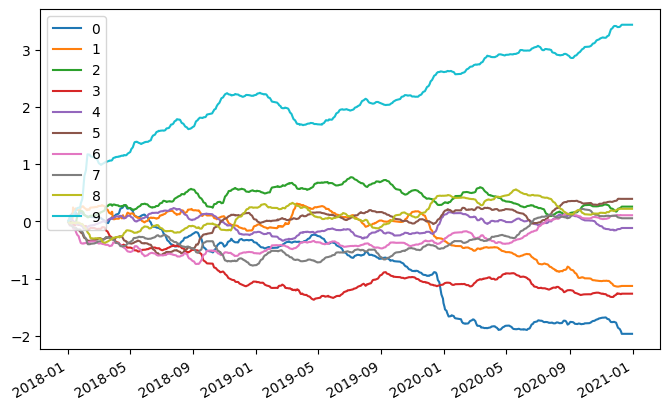

In [81]:
group_ret = calc_group_ret(cov, label)
group_ret = pd.DataFrame(np.nancumsum(group_ret,axis=1).T,index=dates)
group_ret.plot(figsize=(8,5))
plt.show()